In [1]:

import os
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Add the path to the modeling_pipeline.py
sys.path.append(os.path.abspath('../'))

# Import necessary functions from modeling_pipeline.py
from src.modeling_pipeline import (
    prepare_creditcard_dataset,
    prepare_fraud_dataset,
    describe_dataset,
    split_scale_resample,
    evaluate_model,
    tune_xgboost,
    plot_feature_importance,
    shap_explainability
)


import os
import pandas as pd
import shap
from xgboost import XGBClassifier
from src.modeling_pipeline import (
    prepare_creditcard_dataset,
    split_scale_resample,
    shap_explainability
)

warnings.filterwarnings('ignore')
ROOT_DIR = Path.cwd()


### Dataset: CreditCard
Rows: 283,726, Features: 30
Target class distribution:
Class
0    283253
1       473
Percent distribution:
Class
0    99.833
1     0.167
Imbalance ratio = 598.8 : 1
Before SMOTE: [226602    378]
After SMOTE: [226602 226602]
------------------------------------------------------------------------
CreditCard | LogisticRegression | AP: 0.6832 | F1: 0.0985 | ROC-AUC: 0.9586
[[55144  1507]
 [   12    83]]
------------------------------------------------------------------------
Tuning XGBoost...
Fold 1 | AP 0.8140 | F1 0.4175 | ROC-AUC 0.9841
Fold 2 | AP 0.8395 | F1 0.3668 | ROC-AUC 0.9790
Fold 3 | AP 0.7942 | F1 0.3876 | ROC-AUC 0.9696
Fold 4 | AP 0.8355 | F1 0.4110 | ROC-AUC 0.9677
Fold 5 | AP 0.8169 | F1 0.3971 | ROC-AUC 0.9802
CV summary: {'mean_average_precision': np.float64(0.8200146054798424), 'std_average_precision': np.float64(0.016334408621186933), 'mean_f1_score': np.float64(0.39600396175951885), 'std_f1_score': np.float64(0.017964116227300108), 'mean_roc_a

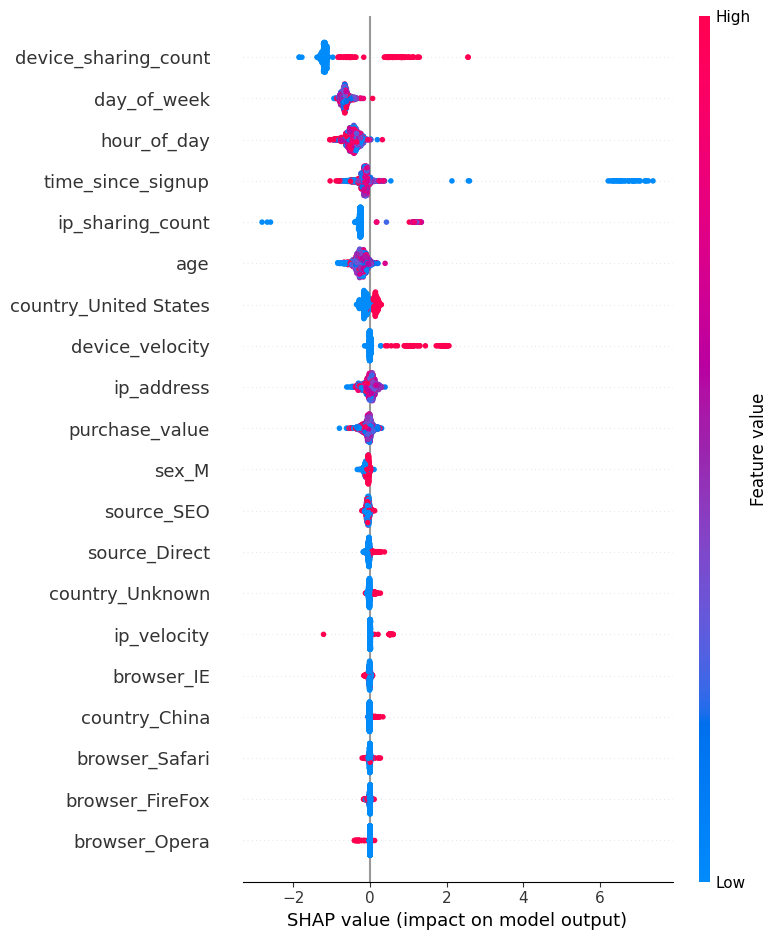

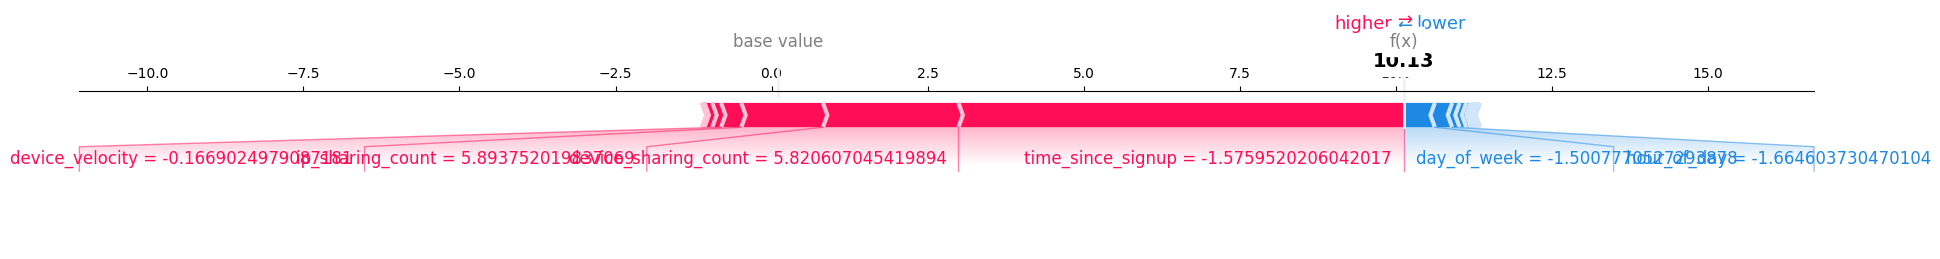

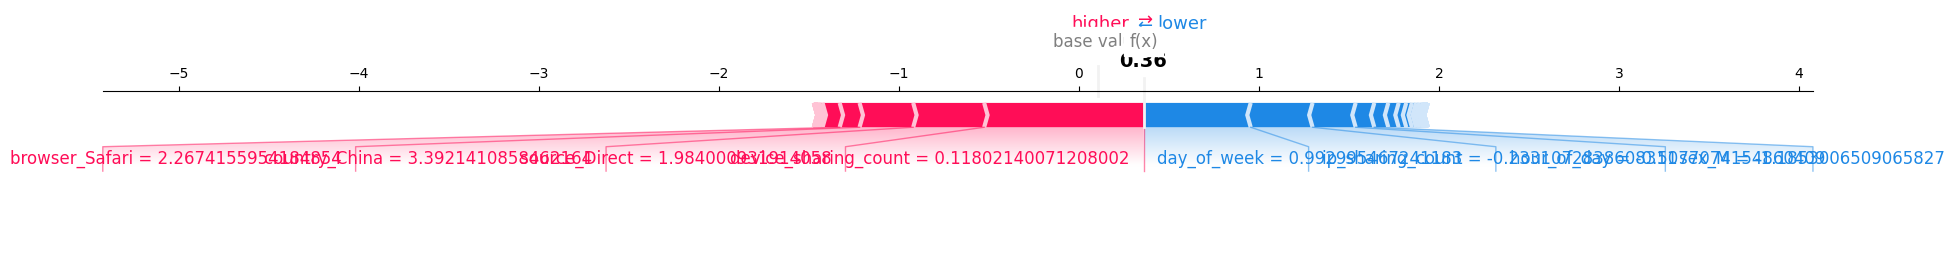

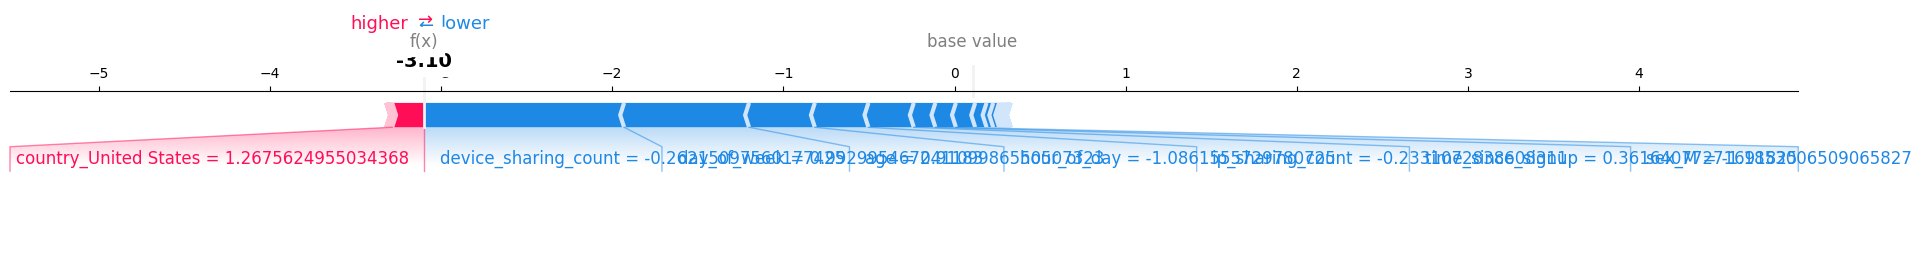

Saved model comparison summary to d:\pro_lang\Python\AI_Training\AI_Training_Projects\challenge_week5\fraud-detection\notebooks\models\reports\model_comparison_summary.csv
      dataset               model  average_precision  f1_score   roc_auc  \
0  CreditCard  LogisticRegression           0.683198  0.098516  0.958601   
1  CreditCard             XGBoost           0.824341  0.835165  0.965445   
2   FraudData  LogisticRegression           0.670924  0.604467  0.837207   
3   FraudData             XGBoost           0.705345  0.683486  0.835966   

      tn    fp    fn    tp  
0  55144  1507    12    83  
1  56640    11    19    76  
2  25631  1762   841  1989  
3  27353    40  1340  1490  


In [2]:

def run_pipeline():
    results = []
    output_dir = ROOT_DIR / 'models' / 'reports'
    output_dir.mkdir(parents=True, exist_ok=True)

    dataset_configs = [
        ('CreditCard', prepare_creditcard_dataset),
        ('FraudData', prepare_fraud_dataset),
    ]

    for dataset_name, prepare_fn in dataset_configs:
        X, y = prepare_fn('data/processed')
        describe_dataset(dataset_name, X, y)

        X_train_scaled, X_test_scaled, y_train, y_test, X_train_res, y_train_res, scaler = split_scale_resample(X, y)

        baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
        baseline.fit(X_train_res, y_train_res)
        results.append(evaluate_model(baseline, X_test_scaled, y_test, 'LogisticRegression', dataset_name))

        # Tune XGBoost on the full dataset and then fit the best ensemble on the train split.
        best_params = tune_xgboost(X, y)
        ensemble = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            n_jobs=-1,
            random_state=42,
            **best_params,
        )
        ensemble.fit(X_train_res, y_train_res)
        results.append(evaluate_model(ensemble, X_test_scaled, y_test, 'XGBoost', dataset_name))

        # Save feature importance for the chosen model
        feature_names = X.columns.tolist()
        importance = plot_feature_importance(ensemble, feature_names, save_path=output_dir / f'{dataset_name}_feature_importance.png')
        importance.to_csv(output_dir / f'{dataset_name}_feature_importance.csv')

        # Save the best model to disk for later explainability if it's the fraud dataset.
        if dataset_name == 'FraudData':
            import joblib
            joblib.dump(ensemble, ROOT_DIR / 'models' / 'best_fraud_xgb.joblib')
            print('Saved FraudData ensemble model artifact.')

            shap_dir = ROOT_DIR / 'models' / 'shap_fraud'
            X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
            shap_explainability(ensemble, X_test_df, y_test.reset_index(drop=True), feature_names, shap_dir)

    summary_df = pd.DataFrame(results)
    summary_path = output_dir / 'model_comparison_summary.csv'
    summary_df.to_csv(summary_path, index=False)
    print(f'Saved model comparison summary to {summary_path}')
    print(summary_df)

# Run the pipeline
run_pipeline()
